In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as layers
import matplotlib.pyplot as plt
import math
import os
import nibabel as nib
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv3D, Input, MaxPooling3D, Dropout, concatenate, UpSampling3D, ReLU
import tensorflow as tf


In [2]:
print(np.__version__)

1.18.5


In [3]:
# resize와 GT resize 를 이용해서 Training 
data_path = "./BTCV_Data/1resize"
gt_path = "./BTCV_Data/gt_resize"


In [4]:
# Train과 Test를 적당한 비율로 나누는 코드(PAth 안에 값 append 시키기)

def get_dataset(data_path, gt_path):
    train_x = []
    train_y = []
    test_x = []
    test_y = []
    test_num = 6
    data_list = sorted(os.listdir(data_path))
    gt_list = sorted(os.listdir(gt_path))
    
    # Train dataset
    for i in range(0, len(data_list)-test_num):
        read_data = data_path + "/" + data_list[i]
        read_gt = gt_path + "/" + gt_list[i]
        
        voxels = nib.load(read_data).get_fdata()
        seg = nib.load(read_gt).get_fdata()
        
        # 0~1로 norm
        # voxels = voxels / 500.0
        voxels = voxels.swapaxes(0,2) 
        seg = seg.swapaxes(0,2) 
        train_x.append(voxels)
        train_y.append(seg)
    
    # Test dataset
    for i in range(len(data_list)-test_num, len(data_list)):
        read_data = data_path + "/" + data_list[i]
        read_gt = gt_path + "/" + gt_list[i]
        
        voxels = nib.load(read_data).get_fdata()
        seg = nib.load(read_gt).get_fdata()
        
        voxels = voxels.swapaxes(0,2) 
        seg = seg.swapaxes(0,2)
        test_x.append(voxels)
        test_y.append(seg)

        
    train_x = np.expand_dims(train_x, axis=-1)
    train_y = np.expand_dims(train_y, axis=-1)
    test_x = np.expand_dims(test_x, axis=-1)
    test_y = np.expand_dims(test_y, axis=-1)
    return train_x, train_y, test_x, test_y 

In [5]:
train_x, train_y, test_x, test_y = get_dataset(data_path, gt_path)
# min_value = np.min(train_x)
# max_value = np.max(train_x)

# train_x = (train_x-min_value) / (max_value-min_value)
# train_y = (train_y-min_value) / (max_value-min_value)
# test_x = (test_x-min_value) / (max_value-min_value)
# test_y = (test_y-min_value) / (max_value-min_value)

train_x = np.array(train_x)
train_y = np.array(train_y)
test_x = np.array(test_x)
test_y = np.array(test_y)

print("train x, y:", train_x.shape, train_y.shape)
print("test x, y:", test_x.shape, test_y.shape)

train x, y: (24, 64, 128, 128, 1) (24, 64, 128, 128, 1)
test x, y: (6, 64, 128, 128, 1) (6, 64, 128, 128, 1)


In [6]:
from tensorflow.python.framework.ops import disable_eager_execution
disable_eager_execution()

def dice_coef_multilabel(y_true, y_pred, labels=11):
#     y_true = tf.convert_to_tensor(y_true)
#     y_pred = tf.convert_to_tensor(y_pred)
    
    #w,h,d = y_true.shape
    y_pred.cpu().numpy
    result = 0
    union = (np.sum(y_pred) + np.sum(y_true))
    #print("union:" + str(union))
    intersection = 0
    for m in range(1,labels+1):
        intersection += np.sum(y_pred[y_true==m])*2.0 
    
        #print("label: "+ str(m) +" intersection: "+str(np.sum(y_pred[y_true==m])*2.0 ))
    dice = intersection / union
#     print("result: "+ str(dice))        
    
    return round(dice,2)

def dice_coef_multilabel_loss(y_true, y_pred, labels=12):
    result = 0
    union = tf.reduce_sum(tf.square(y_pred)) + tf.reduce_sum(tf.square(y_true))
    #print("union:" + str(union))
    intersection = 0
    for m in range(1,labels+1):
        intersection += 2.0 * tf.reduce_sum(y_pred==m * y_true==m)*2.0 
        #print("label: "+ str(m) +" intersection: "+str(np.sum(y_pred[y_true==m])*2.0 ))
    dice = intersection / union
#     print("result: "+ str(dice))        
    
    return 1-round(dice,2)

def dice_coef(y_true, y_pred, smooth=1):
    intersection = K.sum(y_true * y_pred, axis=[1,2,3])
    union = K.sum(y_true, axis=[1,2,3]) + K.sum(y_pred, axis=[1,2,3])
    return K.mean( (2. * intersection + smooth) / (union + smooth), axis=0)

def dice_coe(y_true,y_pred, loss_type='jaccard', smooth=1., labels=11):

    y_true_f = tf.reshape(y_true,[-1])
    y_pred_f = tf.reshape(y_pred,[-1])

    intersection = 0
    for m in range(1,labels+1):
        intersection += np.sum(y_pred[y_true==m])*2.0 

    if loss_type == 'jaccard':
        union = tf.reduce_sum(tf.square(y_pred_f)) + tf.reduce_sum(tf.square(y_true_f))

    elif loss_type == 'sorensen':
        union = tf.reduce_sum(y_pred_f) + tf.reduce_sum(y_true_f)

    else:
        raise ValueError("Unknown `loss_type`: %s" % loss_type)

    return (2. * intersection + smooth) / (union + smooth)

def dice_loss2(y_true, y_pred, loss_type='jaccard', smooth=1.):

    y_true_f = tf.cast(tf.reshape(y_true,[-1]),tf.float32)
    y_pred_f =tf.cast(tf.reshape(y_pred,[-1]),tf.float32)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    if loss_type == 'jaccard':
        union = tf.reduce_sum(tf.square(y_pred_f)) + tf.reduce_sum(tf.square(y_true_f))

    elif loss_type == 'sorensen':
        union = tf.reduce_sum(y_pred_f) + tf.reduce_sum(y_true_f)

    else:
        raise ValueError("Unknown `loss_type`: %s" % loss_type)

    return (1-(2. * intersection + smooth) / (union + smooth))

def dice_loss(y_true, y_pred, eps=0.0001):

    intersection = 2.0 * tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(tf.square(y_pred)) + tf.reduce_sum(tf.square(y_true))
    dice_score = (intersection + eps) / union
    print("intersection", intersection, union, dice_score)
    return 1.0 - dice_score

def _dice_coef_func(y_true, y_pred,
                    smooth=1, class_weight=1,
                    beta=1):
    """
    tp: True positive
    fp: False positive
    fn: False negative
    """
    tp = tf.reduce_sum(
        y_true*y_pred, axis=(0, 1, 2))
    fp = tf.reduce_sum(
        y_pred, axis=(0, 1, 2)) - tp
    fn = tf.reduce_sum(
        y_true, axis=(0, 1, 2)) - tp

    dice = (((1 + beta**2)*tp + smooth)
            /((1 + beta**2)*tp + beta**2*fn + fp + smooth))
    dice = tf.reduce_mean(dice*class_weight)
    return 1- dice

from tensorflow.keras import backend as K

def DCEL(y_true, y_pred, num_classes=2, smooth=1e-7, ignore_background=False):

    y_true = K.one_hot(K.cast(y_true, 'int32'), num_classes=num_classes)[..., 1:] if ignore_background else K.one_hot(
        K.cast(y_true, 'int32'), num_classes=num_classes)
    y_true_f = K.flatten(y_true)
    y_pred = y_pred[..., 1:] if ignore_background else y_pred
    y_pred_f = K.flatten(y_pred)

    intersect = tf.reduce_sum(y_true_f, axis=-1) * tf.reduce_sum(y_pred_f, axis=-1)
    denom = tf.reduce_sum(y_true_f, axis=-1) + tf.reduce_sum(y_pred_f, axis=-1)

    dice = K.mean((2. * intersect / (denom + smooth)))

    return 1-dice

def die(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(K.one_hot(K.cast(y_true, 'int32'), num_classes=12)[...,1:])
    y_pred_f = K.flatten(y_pred[...,1:])
    intersect = K.sum(y_true_f * y_pred_f, axis=-1)
    denom = K.sum(y_true_f + y_pred_f, axis=-1)
    
    return K.mean((2. * intersect / (denom + smooth)))

def die_loss(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(K.one_hot(K.cast(y_true, 'int32'), num_classes=12)[...,1:])
    y_pred_f = K.flatten(y_pred[...,1:])
    intersect = K.sum(y_true_f * y_pred_f, axis=-1)
    denom = K.sum(y_true_f + y_pred_f, axis=-1)
    
    return 1 - K.mean((2. * intersect / (denom + smooth)))



In [7]:
# dex3 = model.get_layer('dex3')
# weights_bias_dex3 = dex3.get_weights()

# dex3.set_weights(weights_bias_dex3)
# dex3.trainable = False

In [8]:
def Unet3D(input_shape = (64,128,128)):
    
    out_channels = 11
    input_channels = 1 
    input_shape = input_shape + (input_channels,)
    x_in = layers.Input(shape=input_shape, name='input')
    
    # Encoder
    x0 = layers.Conv3D(16, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal', name='x0')(x_in)
    x0 = layers.BatchNormalization()(x0)
    x0 = layers.ReLU()(x0)  # 16
    
    x1 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same', kernel_initializer='he_normal', name='x1')(x0)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.ReLU()(x1)  # 16

    x2 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same', kernel_initializer='he_normal', name='x2')(x1)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.ReLU()(x2)  # 8

    x3 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same', kernel_initializer='he_normal', name='x3')(x2)
    x3 = layers.BatchNormalization()(x3)
    x3 = layers.ReLU()(x3)  # 4

    x4 = layers.Conv3D(64, kernel_size=3, strides=2, padding='same', kernel_initializer='he_normal', name='x4')(x3)
    x4 = layers.BatchNormalization()(x4)
    x4 = layers.ReLU()(x4)  # 4
    
    # decoder
    dex4 = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal')(x4)
    dex4 = layers.ReLU()(dex4)
    
    dex4 = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal', name='dex4')(dex4)
    dex4 = layers.ReLU()(dex4)
    dex4 = layers.BatchNormalization()(dex4)
    #     dex4 = layers.UpSampling3D(size=2)(dex4)  # 4
    dex4 = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(dex4)
    dex4 = layers.concatenate([dex4, x3], axis=-1)  # 4

    dex3 = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal')(dex4)
    dex3 = layers.ReLU()(dex3)
    dex3 = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal', name='dex3')(dex3)
    dex3 = layers.ReLU()(dex3)
    dex3 = layers.BatchNormalization()(dex3)
#     dex3 = layers.UpSampling3D(size=2)(dex3)  # 8
    dex3 = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(dex3)
    dex3 = layers.concatenate([dex3, x2], axis=-1)  # 8

    dex2 = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal')(dex3)
    dex2 = layers.ReLU()(dex2)
    dex2 = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal', name='dex2')(dex2)
    dex2 = layers.ReLU()(dex2)
    dex2 = layers.BatchNormalization()(dex2)
#     dex2 = layers.UpSampling3D(size=2)(dex2)  # 16
    dex2 = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(dex2)
    dex2 = layers.concatenate([dex2, x1], axis=-1)  # 16

    dex1 = layers.Conv3D(16, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal')(dex2)
    dex1 = layers.ReLU()(dex1)  # 16
    dex1 = layers.Conv3D(16, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal', name='dex1')(dex1)
    dex1 = layers.ReLU()(dex1)  # 16
    dex1 = layers.BatchNormalization()(dex1)
#     dex1 = layers.UpSampling3D(size=2)(dex1)  
    dex1 = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(dex1)
    dex1 = layers.concatenate([dex1, x0], axis=-1)
    
    dex0 = layers.Conv3D(16, kernel_size=3, strides=1, padding='same', name='dex0')(dex1)
    dex0 = layers.BatchNormalization()(dex0)
    dex0 = layers.ReLU()(dex0)
    
    x = layers.Conv3D(16, kernel_size=3, strides=1, padding='same')(dex0)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    segmentation = layers.Conv3D(out_channels+1, kernel_size=1, strides=1,
                                padding='same',
                                activation = 'softmax',
                                name='segmentation')(x)

    model = Model(inputs={'x_in': x_in}, outputs={'segmentation': segmentation}, name='Unet3D')

    return model 
    
    

In [9]:
batch_size = 4
epochs = 100
lr = 0.001  # learning rate
num_classes = 11
optimizer = tf.keras.optimizers.Adam(lr=lr, epsilon=1e-5)

In [10]:
import tensorflow
early_stop = tensorflow.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=50, restore_best_weights=True) 
checkpoint_path = "./seg_check_points/0803_3cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                   save_weights_only=True,
                                   verbose=1)# Train the model with the new callback

In [11]:
from tensorflow import keras
model = Unet3D()
model.summary()
model.compile(optimizer=Adam(lr=lr), 
              loss= {'segmentation': die_loss},
              metrics=[die])



Model: "Unet3D"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input (InputLayer)              [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
x0 (Conv3D)                     (None, 64, 128, 128, 448         input[0][0]                      
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 64, 128, 128, 64          x0[0][0]                         
__________________________________________________________________________________________________
re_lu (ReLU)                    (None, 64, 128, 128, 0           batch_normalization[0][0]        
_____________________________________________________________________________________________

In [12]:
history = model.fit(train_x, train_y, epochs=epochs, validation_data=(test_x,test_y), batch_size = batch_size)

Train on 24 samples, validate on 6 samples
Epoch 1/100
24/24 [==============================] - ETA: 0s - loss: 0.9672 - die: 0.0328WARNING:tensorflow:From /usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/engine/training_v1.py:2048: Model.state_updates (from tensorflow.python.keras.engine.training) is deprecated and will be removed in a future version.
Instructions for updating:
This property should not be used in TensorFlow 2.0, as updates are applied automatically.
24/24 [==============================] - 3s 140ms/sample - loss: 0.9672 - die: 0.0328 - val_loss: 0.9626 - val_die: 0.0361
Epoch 2/100
24/24 [==============================] - 3s 117ms/sample - loss: 0.9269 - die: 0.0731 - val_loss: 0.9413 - val_die: 0.0567
Epoch 3/100
24/24 [==============================] - 3s 119ms/sample - loss: 0.9112 - die: 0.0888 - val_loss: 0.9651 - val_die: 0.0352
Epoch 4/100
24/24 [==============================] - 3s 116ms/sample - loss: 0.9033 - die: 0.0967 - val_loss: 0.9696 - va

Epoch 58/100
24/24 [==============================] - 3s 118ms/sample - loss: 0.1827 - die: 0.8173 - val_loss: 0.4792 - val_die: 0.5239
Epoch 59/100
24/24 [==============================] - 3s 118ms/sample - loss: 0.1828 - die: 0.8172 - val_loss: 0.4261 - val_die: 0.5990
Epoch 60/100
24/24 [==============================] - 3s 118ms/sample - loss: 0.1757 - die: 0.8243 - val_loss: 0.4692 - val_die: 0.5101
Epoch 61/100
24/24 [==============================] - 3s 118ms/sample - loss: 0.1762 - die: 0.8238 - val_loss: 0.4125 - val_die: 0.6151
Epoch 62/100
24/24 [==============================] - 3s 118ms/sample - loss: 0.1768 - die: 0.8232 - val_loss: 0.4728 - val_die: 0.5312
Epoch 63/100
24/24 [==============================] - 3s 118ms/sample - loss: 0.1735 - die: 0.8265 - val_loss: 0.4549 - val_die: 0.5157
Epoch 64/100
24/24 [==============================] - 3s 118ms/sample - loss: 0.1732 - die: 0.8268 - val_loss: 0.4621 - val_die: 0.5732
Epoch 65/100
24/24 [============================

In [13]:
checkpoint_path = "./seg_check_points/0803_3cp.ckpt"
model.save_weights(checkpoint_path)

In [41]:
checkpoint_path = "./seg_check_points/0725_3cp.ckpt"
model.load_weights(checkpoint_path)

In [38]:
# 특정 weight만 뽑아내보기
dex3 = model.get_layer('dex3')
weights_bias = dex3.get_weights()
# print(weights.shape)
# print(bias.shape)

# model.set_weights(weights)




In [12]:
# Cos Sim 을  위한 코딩
filename1 = "./BTCV_Data/1resize/1.nii.gz"
filename2 = "./BTCV_Data/1resize/40.nii.gz"
data1 = nib.load(filename1).get_fdata()
data1 = np.expand_dims((data1), axis=-1)
data2 = nib.load(filename2).get_fdata()
data2 = np.expand_dims((data2), axis=-1)

# output =.predict(np.expand_dims((x1), axis=0))
x1_model = Model(inputs=model.input, outputs=model.get_layer('x1').output)
f1_x1 = x1_model.predict(np.expand_dims((data1), axis=0))
f2_x1 = x1_model.predict(np.expand_dims((data2), axis=0))
x2_model = Model(inputs=model.input, outputs=model.get_layer('x2').output)
f1_x2 = x2_model.predict(np.expand_dims((data1), axis=0))
f2_x2 = x2_model.predict(np.expand_dims((data2), axis=0))
x3_model = Model(inputs=model.input, outputs=model.get_layer('x3').output)
f1_x3 = x3_model.predict(np.expand_dims((data1), axis=0))
f2_x3 = x3_model.predict(np.expand_dims((data2), axis=0))



def calculate_cos_sim(feat0, feat1):
    f1 = tf.math.l2_normalize(feat0)
    f2 = tf.math.l2_normalize(feat1)
    s = K.sum(f1*f2)
    
    return s / (f1*f2)
    

r1 = calculate_cos_sim(f1_x1, f2_x1)
r2 = calculate_cos_sim(f1_x1, f1_x1)

tf.print(r1, [r1])


In [78]:
def dice_coef(y_true, y_pred_bin):
                    
    intersection = 2.0 * np.sum(y_true * y_pred_bin)
    union = (np.sum(y_true) + np.sum(y_pred_bin))
    if union == 0:
        return 0
    return (intersection / union)

def dice_coef_multilabel(y_true, y_pred, labels=12):
    w,h,d = y_true.shape
    result = 0
    union = (np.sum(y_pred) + np.sum(y_true))
    #print("union:" + str(union))
    intersection = 0
    for m in range(1,labels+1):
        intersection += np.sum(y_pred[y_true==m])*2.0 
    
        #print("label: "+ str(m) +" intersection: "+str(np.sum(y_pred[y_true==m])*2.0 ))
    dice = intersection / union
#     print("result: "+ str(dice))        
    
    return round(dice,2)


filename1 = "./BTCV_Data/gt_resize/40.nii.gz"
# filename2 = "./BTCV_Data/gt_change_vox_r10/" + str(aaa) + ".nii.gz"
if os.path.isfile(filename1):

    x1 = nib.load(filename1).get_fdata()
    x1 = x1.astype(np.float32)
    x2 = nib.load(filename1).get_fdata()
    x2 = x2.astype(np.float32)

    print("Result Dice: "+ str(dice_coef_multilabel(x1,x2,11)))

Result Dice: 1.0


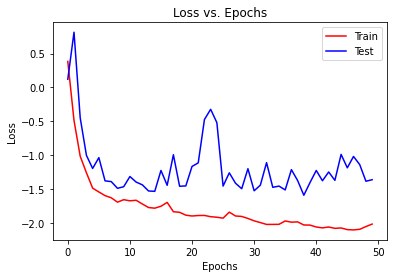

In [40]:
plt.plot(history.history['loss'], color='red', label='Train')
plt.plot(history.history['val_loss'], color='blue', label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")
plt.title('Loss vs. Epochs')
plt.show()
# plt.savefig('loss_plot.png')


In [122]:
input_shape = (128,128,64)
input_channels = 1 
input_shape = input_shape + (input_channels,)

print(input_shape)

(128, 128, 64, 1)


In [11]:
model.summary()

Model: "Unet3D"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input (InputLayer)              [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
x0 (Conv3D)                     (None, 64, 128, 128, 448         input[0][0]                      
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 64, 128, 128, 64          x0[0][0]                         
__________________________________________________________________________________________________
re_lu (ReLU)                    (None, 64, 128, 128, 0           batch_normalization[0][0]        
_____________________________________________________________________________________________

In [13]:
f1model = Model(inputs=model.input, outputs=model.get_layer('conv3d_4').output)
pred2 = f1model.predict(test_x)


a = pred2[5]
print(a.shape)
a = a.swapaxes(0,2) 
print(a.shape)

a = nib.Nifti1Image(a,None) 

nib.save(a,'BTCV_Data/seg_featur4.nii.gz')

(64, 128, 128, 16)
(128, 128, 64, 16)


In [ ]:
def infer(model, image_tensor):
    image_tensor = np.expand_dims((image_tensor), axis=-1)
    predictions = model.predict(np.expand_dims((image_tensor), axis=0))
    predictions = np.squeeze(predictions)
    predictions = np.argmax(predictions, axis=3)
    return predictions

def decode_segmentation_masks(mask, colormap, n_classes):
    l0 = np.zeros_like(mask).astype(np.float32)
    l1 = np.zeros_like(mask).astype(np.float32)
    l2 = np.zeros_like(mask).astype(np.float32)
    l3 = np.zeros_like(mask).astype(np.float32)
    l4 = np.zeros_like(mask).astype(np.float32)
    l5 = np.zeros_like(mask).astype(np.float32)
    l6 = np.zeros_like(mask).astype(np.float32)
    l7 = np.zeros_like(mask).astype(np.float32)
    l8 = np.zeros_like(mask).astype(np.float32)
    l9= np.zeros_like(mask).astype(np.float32)
    l10 = np.zeros_like(mask).astype(np.float32)
    l11 = np.zeros_like(mask).astype(np.float32)
    
    for l in range(0, n_classes):
        idx = mask == l
        l0[idx] = colormap[l, 0]
        l1[idx] = colormap[l, 1]
        l2[idx] = colormap[l, 2]
        l3[idx] = colormap[l, 3]
        l4[idx] = colormap[l, 4]
        l5[idx] = colormap[l, 5]
        l6[idx] = colormap[l, 6]
        l7[idx] = colormap[l, 7]
        l8[idx] = colormap[l, 8]
        l9[idx] = colormap[l, 9]
        l10[idx] = colormap[l, 10]
        l11[idx] = colormap[l, 11]
        
    rgb = np.stack([l0, l1, l2, l3, l4, l5,6], axis=3)
    return rgb


In [ ]:
 nb, nd, nh, nw, nc = tf.shape(deformation)

        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
        # print(grid.shape)
        grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
        multiples = tf.stack([nb, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        # Compute the new sampling grid.moved
        grid_new = grid + deformation
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        # print(grid_new.shape)

        # Sample the moving image using the new sampling grid.
        moved = grid_sample_3d(moving, grid_new, name='moved')